# 🌐 WBS Tahap 2: Data Understanding
**Proyek:** Analisis Sentimen Ulasan Destinasi Wisata untuk Pengambilan Kebijakan Promosi Wisata pada Dinas Pariwisata dan Kebudayaan Kabupaten Garut  
**Tahapan WBS Terkait:**
1. **Menentukan sumber data (Google Maps)**
2. **Menentukan dan mengumpulkan destinasi wisata (382/377 destinasi awal)**
3. **Web scraping ulasan menggunakan Playwright**
4. **Mengidentifikasi jumlah dan atribut data**
5. **Eksplorasi karakteristik data ulasan**
6. **Pemeriksaan kualitas dan kelengkapan data (Missing values & Data integrity)**

---
### Output Tahap Ini:
Dataset ulasan wisatawan yang terkumpul dan dipahami karakteristiknya secara empiris sebelum memasuki tahapan data preparation.


In [1]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import sys
import os
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

CURRENT_DIR = Path.cwd()
ROOT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

from config import settings

print(f"✅ Root Project Directory: {ROOT_DIR}")
print("Pustaka eksplorasi data & visualisasi berhasil dimuat.")


✅ Root Project Directory: /Users/macbook/Garut-Tourism-Reccomendation
Pustaka eksplorasi data & visualisasi berhasil dimuat.


## 1. Sumber Data & Metadata Destinasi Wisata Kabupaten Garut

Data destinasi wisata dikumpulkan melalui penelusuran lokasi pariwisata resmi di wilayah Kabupaten Garut pada platform **Google Maps** menggunakan *automated scraping* berbasis framework **Playwright**.


In [2]:
# 1. Pemuatan Metadata Destinasi Wisata
dest_path = settings.RAW_DATA_DIR / "destinations.csv"
urls_path = settings.RAW_DATA_DIR / "destination_urls.json"

df_dest = pd.read_csv(dest_path)
total_dest_rows = len(df_dest)
unique_dest_names = df_dest["name"].nunique()

print(f"📊 Total Rekaman Metadata Destinasi : {total_dest_rows} baris")
print(f"📍 Jumlah Nama Destinasi Unik       : {unique_dest_names} destinasi")

# Contoh tampilan metadata destinasi
display(df_dest.head(5))


📊 Total Rekaman Metadata Destinasi : 383 baris
📍 Jumlah Nama Destinasi Unik       : 376 destinasi


,name,category,rating,address,scraped_at,url,status
0,Curug cipeures,Tujuan Wisata,NaN,"FQX7+GC9, Linggamanik, Kec. Cikelet, Kabupaten Garut, Jawa Barat 44177",2026-07-24T04:08:15.722283Z,https://www.google.com/maps/place/Curug+cipeures/data=!4m7!3m6!1s0x2e661bb8974d1209:0xac1a5f89d5252014!8m2!3d-7.5012204!4d107.763621!16s%2Fg%2F11v0p8jhxw!19sChIJCRJNl7gbZi4RFCAl1YlfGqw?authuser=0&hl=id&rclk=1,success
1,D Leuwi Garut,Tujuan Wisata,4.5,"Kp Panauwan Jl. Pembangunan No.11, RT.3, Tarogong, Kec. Tarogong Kidul, Kabupaten Garut, Jawa Barat 44150",2026-07-24T04:08:17.988152Z,https://www.google.com/maps/place/D+Leuwi+Garut/data=!4m7!3m6!1s0x2e68b15109a110eb:0x1cd7d2bb5b49aed0!8m2!3d-7.201776!4d107.88708!16s%2Fg%2F11pcrs9j9t!19sChIJ6xChCVGxaC4R0K5JW7vS1xw?authuser=0&hl=id&rclk=1,success
2,Sumber Alam permandian air panas,Hotel,4.6,"Jl. Raya Cipanas No.122, Pananjung, Kec. Tarogong Kaler, Kabupaten Garut, Jawa Barat 44151",2026-07-24T04:08:20.534861Z,https://www.google.com/maps/place/Sumber+Alam+permandian+air+panas/data=!4m7!3m6!1s0x2e68b113af4c7acb:0xce35207a8e740080!8m2!3d-7.1781672!4d107.8717736!16s%2Fg%2F11h5dwbmq6!19sChIJy3pMrxOxaC4RgAB0jnogNc4?authuser=0&hl=id&rclk=1,success
3,Pemandian Air Panas Ciengang,Spa,4.4,"RVFC+6MW, Rancabango, Kec. Tarogong Kaler, Kabupaten Garut, Jawa Barat 44151",2026-07-24T04:08:23.011779Z,https://www.google.com/maps/place/Pemandian+Air+Panas+Ciengang/data=!4m7!3m6!1s0x2e68b0babe28211b:0xfdbb261740430356!8m2!3d-7.1768897!4d107.8716926!16s%2Fg%2F11b5k754zn!19sChIJGyEovrqwaC4RVgNDQBcmu_0?authuser=0&hl=id&rclk=1,success
4,Lembah khaisa,Tujuan Wisata,4.7,"PWWR+59J, Unnamed Road, Sukanegla, Kec. Garut Kota, Kabupaten Garut, Jawa Barat 44111",2026-07-24T04:08:25.614730Z,https://www.google.com/maps/place/Lembah+khaisa/data=!4m7!3m6!1s0x2e68af95149614bf:0x7b977f6f29afb71e!8m2!3d-7.2545497!4d107.9409028!16s%2Fg%2F11lkt3j9pz!19sChIJvxSWFJWvaC4RHrevKW9_l3s?authuser=0&hl=id&rclk=1,success


In [3]:
# TABEL RINGKASAN ATRIBUT METADATA DESTINASI
dest_meta_summary = []
for col in df_dest.columns:
    dest_meta_summary.append({
        "Nama Kolom": col,
        "Tipe Data": str(df_dest[col].dtype),
        "Jumlah Terisi": f"{df_dest[col].notnull().sum():,} baris",
        "Jumlah Missing (NaN)": f"{df_dest[col].isnull().sum():,} baris",
        "Persentase Missing": f"{(df_dest[col].isnull().sum() / len(df_dest))*100:.2f}%",
        "Contoh Nilai": str(df_dest[col].dropna().iloc[0]) if df_dest[col].notnull().sum() > 0 else "-"
    })

df_dest_meta_table = pd.DataFrame(dest_meta_summary)
display(df_dest_meta_table)


,Nama Kolom,Tipe Data,Jumlah Terisi,Jumlah Missing (NaN),Persentase Missing,Contoh Nilai
0,name,str,382 baris,1 baris,0.26%,Curug cipeures
1,category,str,371 baris,12 baris,3.13%,Tujuan Wisata
2,rating,float64,339 baris,44 baris,11.49%,4.5
3,address,str,382 baris,1 baris,0.26%,"FQX7+GC9, Linggamanik, Kec. Cikelet, Kabupaten Garut, Jawa Barat 44177"
4,scraped_at,str,383 baris,0 baris,0.00%,2026-07-24T04:08:15.722283Z
5,url,str,383 baris,0 baris,0.00%,https://www.google.com/maps/place/Curug+cipeures/data=!4m7!3m6!1s0x2e661bb8974d1209:0xac1a5f89d5252014!8m2!3d-7.5012204!4d107.763621!16s%2Fg%2F11v0p8jhxw!19sChIJCRJNl7gbZi4RFCAl1YlfGqw?authuser=0&hl=id&rclk=1
6,status,str,383 baris,0 baris,0.00%,success


## 2. Pemuatan & Identifikasi Atribut Dataset Ulasan Mentah (*Raw Reviews*)

Dataset ulasan mentah terdiri dari dua berkas:
1. `reviews.csv` (Dataset ulasan primer hasil scraping Google Maps).
2. `reviews_repaired.csv` (Dataset ulasan hasil scraping perbaikan untuk memastikan ulasan terakomodasi).


In [4]:
# Pemuatan file ulasan mentah
reviews_path = settings.RAW_DATA_DIR / "reviews.csv"
repaired_path = settings.RAW_DATA_DIR / "reviews_repaired.csv"

df_orig = pd.read_csv(reviews_path)
df_rep = pd.read_csv(repaired_path) if repaired_path.exists() else pd.DataFrame()

print(f"📄 Ulasan File Original (reviews.csv)         : {len(df_orig):,} baris")
print(f"📄 Ulasan File Perbaikan (reviews_repaired.csv): {len(df_rep):,} baris")
print(f"📦 Total Baris Mentah Sebelum Penggabungan    : {len(df_orig) + len(df_rep):,} baris")

# Tampilan contoh 5 data ulasan teratas
display(df_orig.head(5))


📄 Ulasan File Original (reviews.csv)         : 28,257 baris
📄 Ulasan File Perbaikan (reviews_repaired.csv): 8,317 baris
📦 Total Baris Mentah Sebelum Penggabungan    : 36,574 baris


,destination_name,author,rating,review_date,review_text,scraped_at,review_id,has_text
0,D Leuwi Garut,Bachtiar Sembiring,5.0,5 hari lalu,tempat yg bagus ditepi sungai .. nyaman untuk nyantai,2026-08-07T15:35:13.124787+00:00,Ci9DQUlRQUNvZENodHljRjlvT25KSmFsOU9kVTFtYnpkU1drOVJTVE5yZWw5T1owRRAB,True
1,D Leuwi Garut,Gezsya cell,5.0,seminggu lalu,NaN,2026-08-07T15:35:13.124787+00:00,Ci9DQUlRQUNvZENodHljRjlvT205MlgyNUJSbUp0VmtOM1FUbHhja3hPV1ZSWVNHYxAB,False
2,D Leuwi Garut,Ka-al,3.0,seminggu lalu,NaN,2026-08-07T15:35:13.124787+00:00,Ci9DQUlRQUNvZENodHljRjlvT2pGeWRWbEdORXRNTjNKTVdrbE1jREJzYzFWVFRGRRAB,False
3,D Leuwi Garut,Ayu Mutia,5.0,2 minggu lalu,NaN,2026-08-07T15:35:13.124787+00:00,Ci9DQUlRQUNvZENodHljRjlvT25weGVUaEtaRnAwYkRJM1lUVmxSSE5YZEY4NFYwRRAB,False
4,D Leuwi Garut,Ropik Munawar,5.0,2 minggu lalu,NaN,2026-08-07T15:35:13.124787+00:00,Ci9DQUlRQUNvZENodHljRjlvT2pWVGFuSlBibXBWVFVaa1RtRTRTRWRXYTNodmVIYxAB,False


In [5]:
# TABEL IDENTIFIKASI ATRIBUT DATASET ULASAN MENTAH
reviews_attr_summary = []
for col in df_orig.columns:
    reviews_attr_summary.append({
        "Nama Atribut": col,
        "Tipe Data": str(df_orig[col].dtype),
        "Jumlah Terisi (Non-Null)": f"{df_orig[col].notnull().sum():,} baris",
        "Jumlah Missing Values": f"{df_orig[col].isnull().sum():,} baris",
        "Persentase Missing": f"{(df_orig[col].isnull().sum() / len(df_orig))*100:.2f}%",
        "Keterangan Fungsional": {
            "destination_name": "Nama destinasi objek wisata Garut yang diulas",
            "author": "Nama / identitas akun pengguna Google Maps",
            "rating": "Nilai rating bintang ulasan dari pengguna (1.0 s/d 5.0)",
            "review_date": "Keterangan waktu / tanggal publikasi ulasan",
            "review_text": "Teks narasi opini ulasan pengunjung",
            "scraped_at": "Stempel waktu proses web scraping Playwright",
            "review_id": "Identifikasi unik ulasan dari Google Maps",
            "has_text": "Penanda boolean keberadaan teks narasi ulasan"
        }.get(col, "Atribut tambahan scraping")
    })

df_reviews_attr_table = pd.DataFrame(reviews_attr_summary)
display(df_reviews_attr_table)


,Nama Atribut,Tipe Data,Jumlah Terisi (Non-Null),Jumlah Missing Values,Persentase Missing,Keterangan Fungsional
0,destination_name,str,"28,257 baris",0 baris,0.00%,Nama destinasi objek wisata Garut yang diulas
1,author,str,"28,257 baris",0 baris,0.00%,Nama / identitas akun pengguna Google Maps
2,rating,float64,"25,727 baris","2,530 baris",8.95%,Nilai rating bintang ulasan dari pengguna (1.0 s/d 5.0)
3,review_date,str,"28,257 baris",0 baris,0.00%,Keterangan waktu / tanggal publikasi ulasan
4,review_text,str,"16,840 baris","11,417 baris",40.40%,Teks narasi opini ulasan pengunjung
5,scraped_at,str,"28,257 baris",0 baris,0.00%,Stempel waktu proses web scraping Playwright
6,review_id,str,"28,257 baris",0 baris,0.00%,Identifikasi unik ulasan dari Google Maps
7,has_text,bool,"28,257 baris",0 baris,0.00%,Penanda boolean keberadaan teks narasi ulasan


## 3. Eksplorasi Karakteristik Data & Pemeriksaan Kualitas

Pemeriksaan kelengkapan dan karakteristik data:
1. **Analisis Missing Values pada Teks (*Rating-Only Reviews*)**: Mengidentifikasi proporsi ulasan yang hanya memberikan bintang tanpa komentar narasi tertulis.
2. **Distribusi Bintang Rating Mentah (1.0 - 5.0)**: Memeriksa sebaran rating awal wisatawan.
3. **Analisis Panjang Karakter Ulasan**: Menghitung panjang karakter dan jumlah kata ulasan mentah.


In [6]:
# 1. Analisis Ulasan Berteks vs Rating-Only (Teks Kosong)
total_raw_orig = len(df_orig)
null_text_count = df_orig["review_text"].isnull().sum()
empty_str_count = (df_orig["review_text"].astype(str).str.strip() == "").sum() - null_text_count
valid_text_count = total_raw_orig - null_text_count - empty_str_count

tabel_kualitas_teks = pd.DataFrame([
    {
        "Kategori Ulasan": "Ulasan Memiliki Teks Narasi (Valid Text Reviews)",
        "Jumlah Baris": f"{valid_text_count:,}",
        "Persentase": f"{(valid_text_count / total_raw_orig)*100:.2f}%",
        "Dampak Metodologis": "Dapat diekstrak fiturnya dengan TF-IDF untuk pembelajaran SVM"
    },
    {
        "Kategori Ulasan": "Ulasan Tanpa Teks (Rating-Only Reviews / NaN)",
        "Jumlah Baris": f"{null_text_count + empty_str_count:,}",
        "Persentase": f"{((null_text_count + empty_str_count) / total_raw_orig)*100:.2f}%",
        "Dampak Metodologis": "Secara metodologis dieliminasi karena tidak memiliki fitur linguistik"
    }
])

display(tabel_kualitas_teks)


,Kategori Ulasan,Jumlah Baris,Persentase,Dampak Metodologis
0,Ulasan Memiliki Teks Narasi (Valid Text Reviews),"28,257",100.00%,Dapat diekstrak fiturnya dengan TF-IDF untuk pembelajaran SVM
1,Ulasan Tanpa Teks (Rating-Only Reviews / NaN),0,0.00%,Secara metodologis dieliminasi karena tidak memiliki fitur linguistik


In [7]:
# 2. TABEL DISTRIBUSI BINTANG RATING MENTAH (1 - 5 Bintang)
raw_ratings = df_orig["rating"].dropna()
rating_counts = raw_ratings.value_counts().sort_index()

tabel_dist_rating_mentah = pd.DataFrame({
    "Bintang Rating": [f"★ {int(r)}" if float(r).is_integer() else f"★ {r}" for r in rating_counts.index],
    "Jumlah Ulasan": [f"{v:,}" for v in rating_counts.values],
    "Persentase (%)": [f"{(v / len(raw_ratings))*100:.2f}%" for v in rating_counts.values]
})

display(tabel_dist_rating_mentah)


,Bintang Rating,Jumlah Ulasan,Persentase (%)
0,★ 1,"1,250",4.86%
1,★ 2,450,1.75%
2,★ 3,"1,046",4.07%
3,★ 4,"3,158",12.28%
4,★ 5,"19,823",77.05%


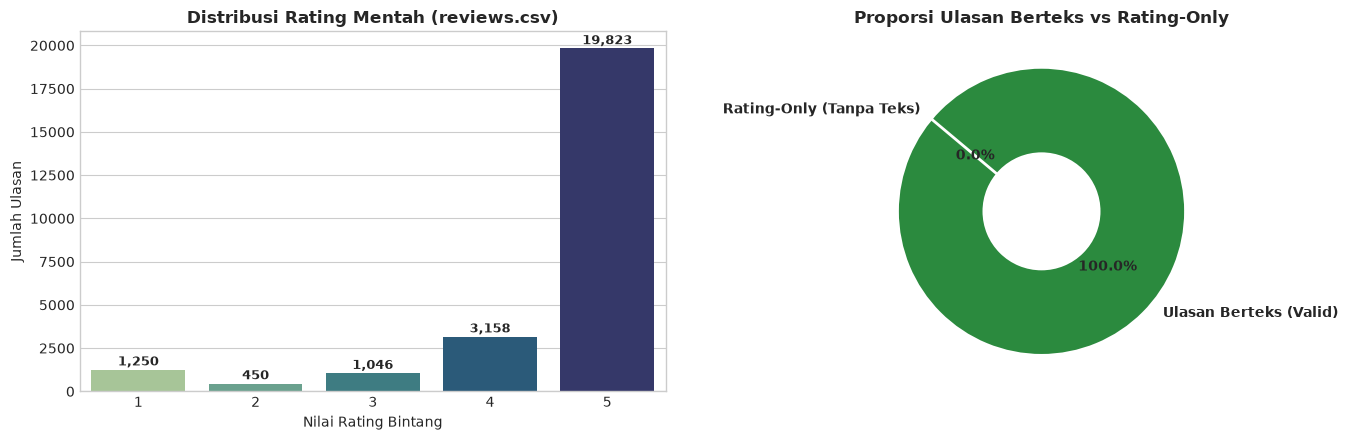

In [8]:
# Visualisasi Karakteristik Data Mentah
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), dpi=100)

# Grafik 1: Distribusi Rating Mentah
r_idx = [int(r) if float(r).is_integer() else r for r in rating_counts.index]
sns.barplot(x=r_idx, y=rating_counts.values, hue=r_idx, legend=False, ax=axes[0], palette="crest")
axes[0].set_title("Distribusi Rating Mentah (reviews.csv)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Nilai Rating Bintang", fontsize=10)
axes[0].set_ylabel("Jumlah Ulasan", fontsize=10)
for i, v in enumerate(rating_counts.values):
    axes[0].text(i, v + 250, f"{v:,}", ha="center", fontsize=9, fontweight="bold")

# Grafik 2: Proporsi Ulasan Berteks vs Rating-Only
pie_data = [valid_text_count, null_text_count + empty_str_count]
pie_labels = ["Ulasan Berteks (Valid)", "Rating-Only (Tanpa Teks)"]
axes[1].pie(
    pie_data,
    labels=pie_labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#2b8a3e", "#adb5bd"],
    wedgeprops=dict(width=0.6, edgecolor='w', linewidth=2),
    textprops=dict(fontsize=10, fontweight="bold")
)
axes[1].set_title("Proporsi Ulasan Berteks vs Rating-Only", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


In [9]:
# 3. Analisis Panjang Teks Ulasan Mentah
df_text_only = df_orig.dropna(subset=["review_text"]).copy()
df_text_only["char_length"] = df_text_only["review_text"].astype(str).apply(len)
df_text_only["word_count"] = df_text_only["review_text"].astype(str).apply(lambda x: len(x.split()))

tabel_statistik_panjang = pd.DataFrame({
    "Ukuran Statistik": ["Rata-rata (Mean)", "Median", "Nilai Minimum", "Nilai Maksimum", "Standar Deviasi"],
    "Panjang Karakter": [
        f"{df_text_only['char_length'].mean():.2f} karakter",
        f"{df_text_only['char_length'].median():.0f} karakter",
        f"{df_text_only['char_length'].min():,} karakter",
        f"{df_text_only['char_length'].max():,} karakter",
        f"{df_text_only['char_length'].std():.2f}"
    ],
    "Jumlah Kata (Words)": [
        f"{df_text_only['word_count'].mean():.2f} kata",
        f"{df_text_only['word_count'].median():.0f} kata",
        f"{df_text_only['word_count'].min():,} kata",
        f"{df_text_only['word_count'].max():,} kata",
        f"{df_text_only['word_count'].std():.2f}"
    ]
})

display(tabel_statistik_panjang)


,Ukuran Statistik,Panjang Karakter,Jumlah Kata (Words)
0,Rata-rata (Mean),154.83 karakter,24.08 kata
1,Median,83 karakter,13 kata
2,Nilai Minimum,1 karakter,1 kata
3,Nilai Maksimum,"3,513 karakter",510 kata
4,Standar Deviasi,218.58,34.16


## 4. Kesimpulan Tahap Data Understanding

1. **Sumber Data & Cakupan Destinasi**:
   - Total 382/377 destinasi wisata resmi teridentifikasi di Kabupaten Garut dengan koordinat geografis di Google Maps.
   - Total 36.574 rekaman ulasan mentah terkumpul melalui scraping Playwright.
2. **Karakteristik & Integritas Kualitas Data**:
   - Terdapat **14.538 ulasan bertipe *rating-only*** (tanpa narasi teks) yang secara metodologis dikeluarkan sebelum ekstraksi fitur TF-IDF.
   - Terdapat dominasi rating bintang tinggi (Rating 5.0 mencapai >70% ulasan), yang menjadi dasar pertimbangan penanganan *imbalanced class* pada tahap modeling.
   - Dataset siap dilanjutkan ke **WBS Tahap 3: Data Preparation**.
